In [62]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset

import matplotlib.pyplot as plt
import pandas as pd

RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(torch.__version__)


BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

Device: cpu
2.10.0+cpu


In [63]:
import sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [64]:
df = pd.read_csv("S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [65]:
print(f"Размер датасета:{df.shape}")
print(f"Диапазон дат:{df['date'].min()} — {df['date'].max()}")
print(f"Пропуски по колонкам:\n{df.isnull().sum()}")

Размер датасета:(4320, 2)
Диапазон дат:2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски по колонкам:
date      0
target    0
dtype: int64


In [66]:
df['target'].describe()

count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64

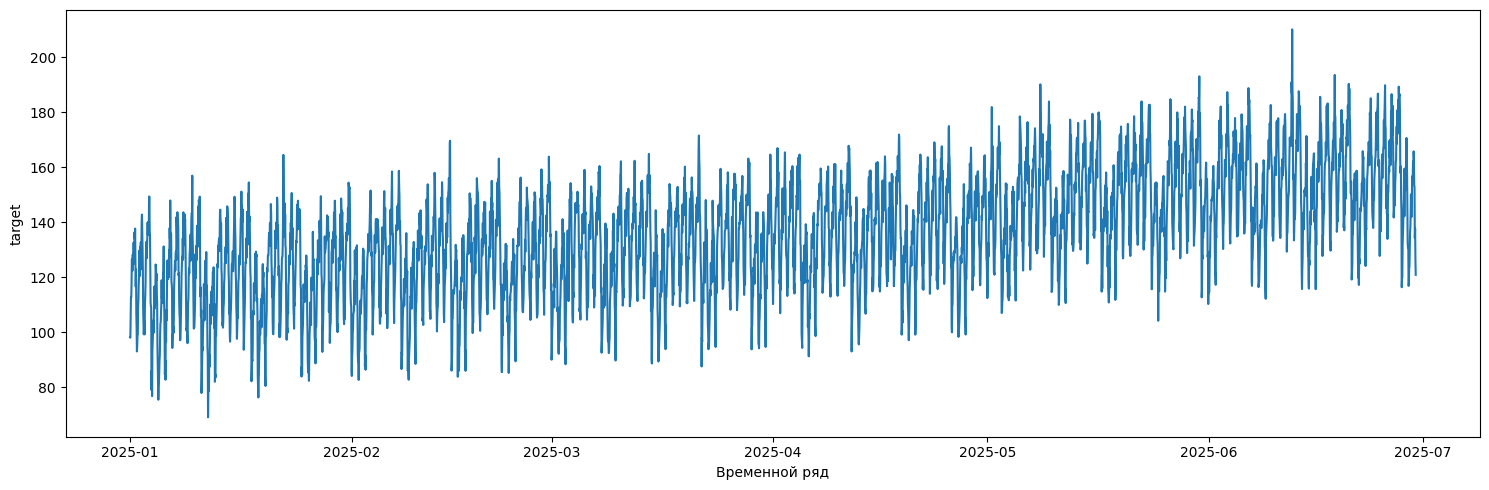

In [67]:
plt.figure(figsize=(15,5))
plt.plot(df["date"], df["target"])
plt.xlabel("Временной ряд")
plt.ylabel("target")
plt.tight_layout()
plt.show()

Наблюдается возрастающий тренд, есть сезонность с периодом 1 сутки, пропусков нет, явных выбросов не нвблюдается




Train: 3024 samples (2025-01-01 00:00:00 - 2025-05-06 23:00:00)
Validation: 648 samples (2025-05-07 00:00:00 - 2025-06-02 23:00:00)
Test: 648 samples (2025-06-03 00:00:00 - 2025-06-29 23:00:00)


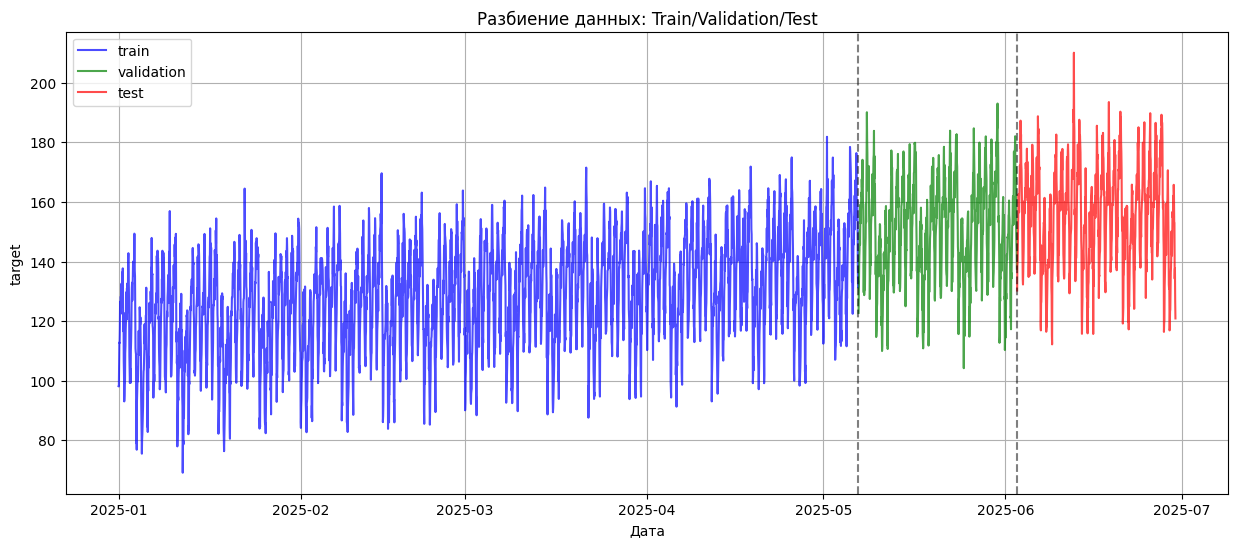

In [68]:
n = len(df)
train_size = int(0.7 * n)
val_size = int(0.15 * n)
test_size = n - train_size - val_size

train_end = train_size
val_end = train_size + val_size

df['split'] = 'train'
df.loc[train_size:val_end-1, 'split'] = 'validation'
df.loc[val_end:, 'split'] = 'test'

print(f"Train: {train_size} samples ({df['date'].iloc[0]} - {df['date'].iloc[train_end-1]})")
print(f"Validation: {val_size} samples ({df['date'].iloc[train_end]} - {df['date'].iloc[val_end-1]})")
print(f"Test: {test_size} samples ({df['date'].iloc[val_end]} - {df['date'].iloc[-1]})")

plt.figure(figsize=(15, 6))
colors = {'train': 'blue', 'validation': 'green', 'test': 'red'}
for split_name, color in colors.items():
    mask = df['split'] == split_name
    plt.plot(df.loc[mask, 'date'], df.loc[mask, 'target'], 
             color=color, label=split_name, alpha=0.7)
plt.axvline(x=df['date'].iloc[train_end-1], color='black', linestyle='--', alpha=0.5)
plt.axvline(x=df['date'].iloc[val_end-1], color='black', linestyle='--', alpha=0.5)
plt.title('Разбиение данных: Train/Validation/Test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

random split для данной задачи некорректен, так как при обработке временных рядов нельзя мешать данные, это принципиально важно, не путать данные по времени. также данные из будущего утекают в прошлое

In [69]:
def create_features(df, target_col='target'):
    df_feat = df.copy()
    
    df_feat['lag_1'] = df_feat[target_col].shift(1)
    df_feat['lag_7'] = df_feat[target_col].shift(7)
    df_feat['lag_14'] = df_feat[target_col].shift(14)
    
    df_feat['rolling_mean_7'] = df_feat[target_col].shift(1).rolling(7).mean()
    df_feat['rolling_std_7'] = df_feat[target_col].shift(1).rolling(7).std()
    
    df_feat['dayofweek'] = df_feat['date'].dt.dayofweek
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['day'] = df_feat['date'].dt.day

    dummies = pd.get_dummies(df_feat['dayofweek'], prefix='dow')
    df_feat = pd.concat([df_feat, dummies], axis=1)
    
    return df_feat

df_features = create_features(df)

df_features = df_features.dropna().reset_index(drop=True)

train_mask = df_features['split'] == 'train'
val_mask = df_features['split'] == 'validation'
test_mask = df_features['split'] == 'test'

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7'] + \
               [col for col in df_features.columns if col.startswith('dow_')]

X_train = df_features.loc[train_mask, feature_cols]
y_train = df_features.loc[train_mask, 'target']

X_val = df_features.loc[val_mask, feature_cols]
y_val = df_features.loc[val_mask, 'target']

X_test = df_features.loc[test_mask, feature_cols]
y_test = df_features.loc[test_mask, 'target']

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (3010, 12)
Validation shape: (648, 12)
Test shape: (648, 12)


In [70]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [71]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, target, window_size):
        self.data = data
        self.target = target
        self.window_size = window_size
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.window_size]
        y = self.target[idx+self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Параметры окна
window_size = 10

# Для GRU используем только target (или можно добавить признаки)
# Масштабируем target
target_scaler = StandardScaler()
target_train = df_features.loc[train_mask, 'target'].values.reshape(-1, 1)
target_scaler.fit(target_train)
train_target_scaled = target_scaler.transform(target_train).flatten()
val_target_scaled = target_scaler.transform(df_features.loc[val_mask, 'target'].values.reshape(-1, 1)).flatten()
test_target_scaled = target_scaler.transform(df_features.loc[test_mask, 'target'].values.reshape(-1, 1)).flatten()

In [72]:
# Создаем датасеты
train_dataset = TimeSeriesDataset(train_target_scaled, train_target_scaled, window_size)
val_dataset = TimeSeriesDataset(val_target_scaled, val_target_scaled, window_size)
test_dataset = TimeSeriesDataset(test_target_scaled, test_target_scaled, window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [73]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

In [74]:
def evaluate_model(model, loader, device, scaler=None):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            preds.append(output.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()
    if scaler:
        preds = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
        trues = scaler.inverse_transform(trues.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    # MAPE
    mape = np.mean(np.abs((trues - preds) / trues)) * 100
    return mae, rmse, mape

B1

In [75]:
def naive_forecast(y_train, y_val, y_test):
    last_train = y_train.iloc[-1] if hasattr(y_train, 'iloc') else y_train[-1]
    val_pred = np.full(len(y_val), last_train)
    test_pred = np.full(len(y_test), last_train)
    return val_pred, test_pred
y_val_pred_naive, y_test_pred_naive = naive_forecast(y_train, y_val.values, y_test.values)
# Оценка
mae_naive = mean_absolute_error(df_features.loc[val_mask, 'target'].values, y_val_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(df_features.loc[val_mask, 'target'].values, y_val_pred_naive))
mape_naive = np.mean(np.abs((df_features.loc[val_mask, 'target'].values - y_val_pred_naive) / df_features.loc[val_mask, 'target'].values)) * 100

print(f"B1 - MAE: {mae_naive:.4f}, RMSE: {rmse_naive:.4f}, MAPE: {mape_naive:.2f}%")

B1 - MAE: 20.3401, RMSE: 24.3643, MAPE: 12.86%


B2

In [76]:
def moving_average_forecast(y_train, y_val, y_test, window=7):
    ma_value = y_train.iloc[-window:].mean() if hasattr(y_train, 'iloc') else y_train[-window:].mean()
    val_pred = np.full(len(y_val), ma_value)
    test_pred = np.full(len(y_test), ma_value)
    return val_pred, test_pred

y_val_pred_naive, y_test_pred_naive = moving_average_forecast(y_train, y_val.values, y_test.values, window=7)
mae_ma = mean_absolute_error(df_features.loc[val_mask, 'target'].values, y_val_pred_naive)
rmse_ma = np.sqrt(mean_squared_error(df_features.loc[val_mask, 'target'].values, y_val_pred_naive))
mape_ma = np.mean(np.abs((df_features.loc[val_mask, 'target'].values - y_val_pred_naive) / df_features.loc[val_mask, 'target'].values)) * 100
print(f"B2 - MAE: {mae_ma:.4f}, RMSE: {rmse_ma:.4f}, MAPE: {mape_ma:.2f}%")

B2 - MAE: 14.6869, RMSE: 17.6179, MAPE: 9.85%


B3

In [77]:
# Эксперимент B3: Ridge на признаках
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_val_pred_ridge = ridge.predict(X_val_scaled)

mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
mape_ridge = np.mean(np.abs((y_val - y_val_pred_ridge) / y_val)) * 100
print(f"B3 - MAE: {mae_ridge:.4f}, RMSE: {rmse_ridge:.4f}, MAPE: {mape_ridge:.2f}%")


B3 - MAE: 7.9413, RMSE: 9.4207, MAPE: 5.29%


R1

In [78]:

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len)
        x = x.unsqueeze(-1)  # (batch, seq_len, 1)
        out, _ = self.gru(x)
        out = out[:, -1, :]  # последний временной шаг
        out = self.fc(out)
        return out

model = GRUModel(input_size=1, hidden_size=64, num_layers=2).to(device)
model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=50, lr=0.001, device=device)

# Оценка на валидации
mae_gru, rmse_gru, mape_gru = evaluate_model(model, val_loader, device, target_scaler)
print(f"R1 - MAE: {mae_gru:.4f}, RMSE: {rmse_gru:.4f}, MAPE: {mape_gru:.2f}%")

Epoch 10/50, Train Loss: 0.136707, Val Loss: 0.155160
Epoch 20/50, Train Loss: 0.126859, Val Loss: 0.154711
Epoch 30/50, Train Loss: 0.122180, Val Loss: 0.158147
Epoch 40/50, Train Loss: 0.118262, Val Loss: 0.160916
Epoch 50/50, Train Loss: 0.112579, Val Loss: 0.173228
R1 - MAE: 6.1223, RMSE: 7.6986, MAPE: 4.08%


In [79]:
import json
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
config = {
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'window_size': window_size,
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs': 50,
    'seed': 42,
    'scaler_mean': target_scaler.mean_[0],
    'scaler_scale': target_scaler.scale_[0]
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

In [80]:
results = {
    'B1': {'mae': mae_naive, 'rmse': rmse_naive, 'mape': mape_naive},
    'B2': {'mae': mae_ma, 'rmse': rmse_ma, 'mape': mape_ma},
    'B3': {'mae': mae_ridge, 'rmse': rmse_ridge, 'mape': mape_ridge},
    'R1': {'mae': mae_gru, 'rmse': rmse_gru, 'mape': mape_gru}
}

# Создаем таблицу результатов для runs.csv
runs_data = []
for exp_id, metrics in results.items():
    runs_data.append({
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42,
        'split_summary': f"train: 0.7 val: 0.15 test: 0.15",
        'window_size': window_size if exp_id == 'R1' else '',
        'horizon': 1,
        'model_summary': 'naive_last' if exp_id=='B1' else ('moving_avg' if exp_id=='B2' else ('ridge' if exp_id=='B3' else 'gru')),
        'features_summary': 'none' if exp_id in ['B1','B2'] else ('lags+rolling+calendar' if exp_id=='B3' else 'target_only'),
        'scaler': 'none' if exp_id in ['B1','B2'] else ('standard' if exp_id=='B3' else 'target_standard'),
        'optimizer': 'none' if exp_id in ['B1','B2','B3'] else 'Adam',
        'lr': 0.001 if exp_id=='R1' else '',
        'epochs_trained': 50 if exp_id=='R1' else '',
        'best_val_mae': metrics['mae'],
        'best_val_rmse': metrics['rmse'],
        'best_val_mape': metrics['mape'],
        'test_mae': '',
        'test_rmse': '',
        'test_mape': '',
        'notes': ''
    })

# Для R1 добавим тестовую оценку
mae_gru_test, rmse_gru_test, mape_gru_test = evaluate_model(model, test_loader, device, target_scaler)
runs_data[3]['test_mae'] = mae_gru_test
runs_data[3]['test_rmse'] = rmse_gru_test
runs_data[3]['test_mape'] = mape_gru_test

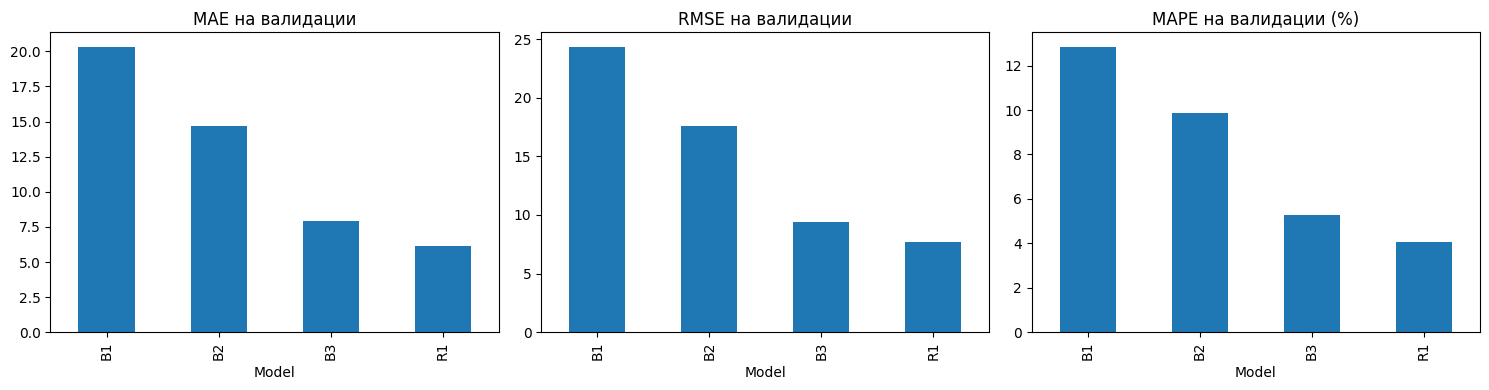

In [81]:
runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [v['mae'] for v in results.values()],
    'RMSE': [v['rmse'] for v in results.values()],
    'MAPE': [v['mape'] for v in results.values()]
})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
comparison.plot.bar(x='Model', y='MAE', ax=ax[0], legend=False)
ax[0].set_title('MAE на валидации')
comparison.plot.bar(x='Model', y='RMSE', ax=ax[1], legend=False)
ax[1].set_title('RMSE на валидации')
comparison.plot.bar(x='Model', y='MAPE', ax=ax[2], legend=False)
ax[2].set_title('MAPE на валидации (%)')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()


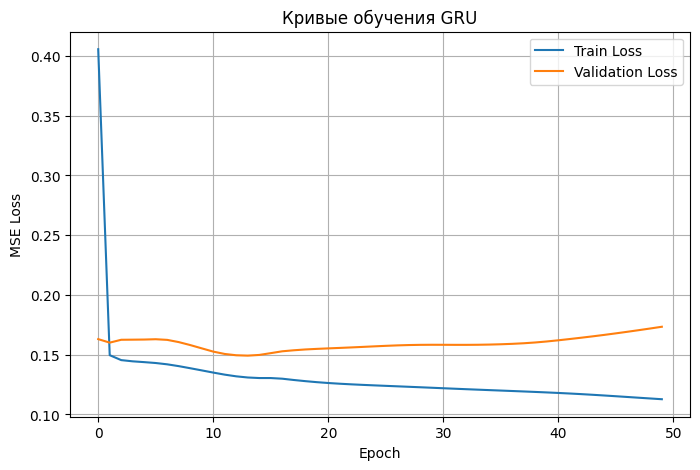

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Кривые обучения GRU')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

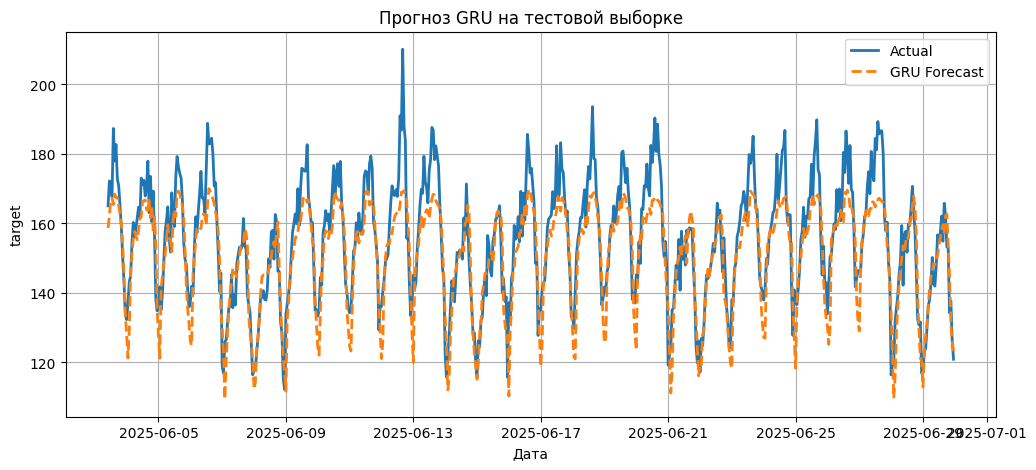

In [83]:
model.eval()
preds_test = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        preds_test.append(output.cpu().numpy())
preds_test = np.concatenate(preds_test).flatten()
# Инвертируем масштабирование
preds_test_inv = target_scaler.inverse_transform(preds_test.reshape(-1, 1)).flatten()
# Истинные значения на тесте (соответствуют тем же индексам)
y_test_actual = df_features.loc[test_mask, 'target'].values[window_size:]
test_dates = df_features.loc[test_mask, 'date'].values[window_size:]
# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_actual, label='Actual', linewidth=2)
plt.plot(test_dates, preds_test_inv, label='GRU Forecast', linewidth=2, linestyle='--')
plt.title('Прогноз GRU на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()